# RAG & Vector Databases
**Retrieval-Augmented Generation** concepts demonstrated with code.
Prerequisites: `pip install numpy scikit-learn matplotlib`

📺 **Video Lecture:** [https://youtu.be/zw4WmjWg3LY](https://youtu.be/zw4WmjWg3LY)

In [25]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. What Are Embeddings?
Embeddings map text to dense vectors. Here we simulate word embeddings.

In [26]:
# Simulated word embeddings (normally from a model like sentence-transformers)
words = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 'dog', 'cat']
# Simulate 8 words in 5-D space with semantic clusters
embeddings = {
    'king':     np.array([0.9, 0.1, 0.8, 0.2, 0.7]),
    'queen':    np.array([0.9, 0.1, 0.2, 0.8, 0.7]),
    'man':      np.array([0.7, 0.2, 0.9, 0.1, 0.3]),
    'woman':    np.array([0.7, 0.2, 0.1, 0.9, 0.3]),
    'prince':   np.array([0.85, 0.15, 0.75, 0.25, 0.6]),
    'princess': np.array([0.85, 0.15, 0.25, 0.75, 0.6]),
    'dog':      np.array([0.1, 0.9, 0.5, 0.5, 0.1]),
    'cat':      np.array([0.1, 0.85, 0.5, 0.5, 0.15]),
}
emb_matrix = np.array([embeddings[w] for w in words])
print('Embedding matrix shape:', emb_matrix.shape)

Embedding matrix shape: (8, 5)


## 2. Cosine Similarity — The Heart of Vector Search

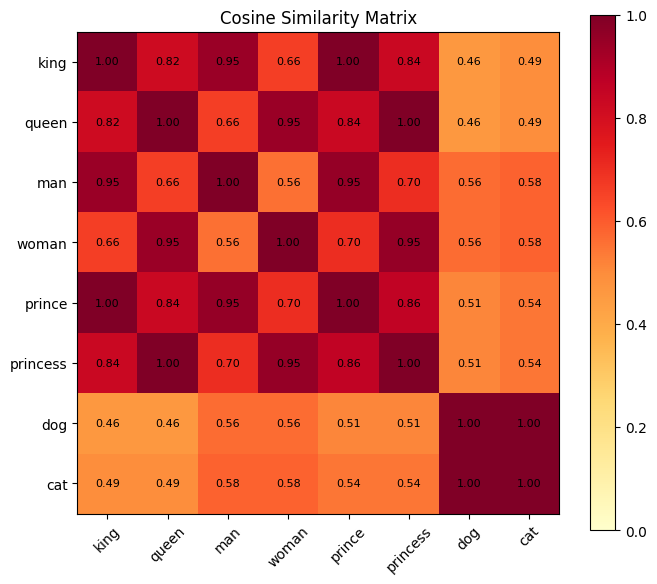

In [27]:
sim_matrix = cosine_similarity(emb_matrix)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45)
ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); plt.title('Cosine Similarity Matrix'); plt.tight_layout(); plt.show()

## 3. Building a Simple Vector Store
A minimal vector database: store documents, embed them, retrieve by similarity.

In [28]:
class SimpleVectorStore:
    """Minimal in-memory vector store for demonstration."""
    def __init__(self, dim):
        self.dim = dim
        self.docs = []       # list of (text, embedding)
    
    def add(self, text, embedding):
        self.docs.append((text, embedding / np.linalg.norm(embedding)))
    
    def search(self, query_emb, top_k=3):
        q = query_emb / np.linalg.norm(query_emb)
        scores = [(text, float(np.dot(q, emb))) for text, emb in self.docs]
        return sorted(scores, key=lambda x: -x[1])[:top_k]

# Create store and add sample documents
store = SimpleVectorStore(dim=64)
np.random.seed(0)
topics = [
    'Python is a popular programming language for data science.',
    'Neural networks are inspired by biological neurons.',
    'Transformers use self-attention for sequence modeling.',
    'RAG combines retrieval with generation for better answers.',
    'Vector databases store and search embeddings efficiently.',
    'Fine-tuning adapts a pre-trained model to a specific task.',
    'Gradient descent minimizes the loss function iteratively.',
    'Convolutional layers detect spatial patterns in images.',
]
# Simulate embeddings (in practice, use sentence-transformers)
for doc in topics:
    emb = np.random.randn(64)
    store.add(doc, emb)

# Query
query_emb = np.random.randn(64)
results = store.search(query_emb, top_k=3)
print('Top-3 retrieved documents:')
for text, score in results:
    print(f'  [{score:.4f}] {text}')

Top-3 retrieved documents:
  [0.1754] Convolutional layers detect spatial patterns in images.
  [0.1414] Vector databases store and search embeddings efficiently.
  [0.1335] Fine-tuning adapts a pre-trained model to a specific task.


## 4. RAG Pipeline Simulation
RAG = **Retrieve** relevant context → **Augment** the prompt → **Generate** answer.

In [29]:
def simulate_rag(question, store, top_k=2):
    """Simulate a RAG pipeline (no real LLM — just shows the flow)."""
    # Step 1: Embed the question (simulated)
    query_emb = np.random.randn(store.dim)
    
    # Step 2: Retrieve
    retrieved = store.search(query_emb, top_k=top_k)
    context = '\n'.join([doc for doc, _ in retrieved])
    
    # Step 3: Augment prompt
    augmented_prompt = (
        f'Context:\n{context}\n\n'
        f'Question: {question}\n'
        f'Answer based on the context above:'
    )
    
    # Step 4: Generate (simulated — in practice call an LLM)
    print('=== RAG Pipeline ===')
    print(f'Question: {question}')
    print(f'\nRetrieved {top_k} documents:')
    for doc, score in retrieved:
        print(f'  [{score:.3f}] {doc}')
    print(f'\nAugmented Prompt:\n{augmented_prompt}')
    print('\n[LLM would generate answer here]')

simulate_rag('How does RAG work?', store)

=== RAG Pipeline ===
Question: How does RAG work?

Retrieved 2 documents:
  [0.194] Fine-tuning adapts a pre-trained model to a specific task.
  [0.085] Convolutional layers detect spatial patterns in images.

Augmented Prompt:
Context:
Fine-tuning adapts a pre-trained model to a specific task.
Convolutional layers detect spatial patterns in images.

Question: How does RAG work?
Answer based on the context above:

[LLM would generate answer here]


## 5. Chunking Strategies
Large documents must be split into chunks before embedding.

Text length: 400 chars
Number of chunks: 5
Chunk sizes: [100, 100, 100, 100, 80]


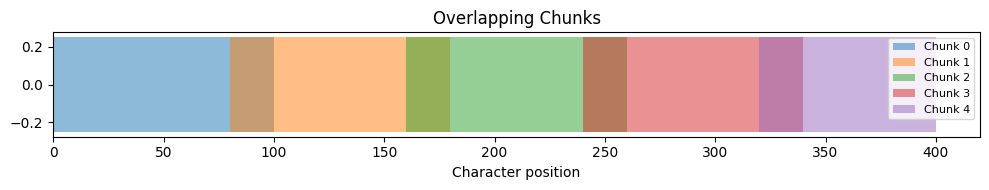

In [30]:
def fixed_size_chunks(text, chunk_size=100, overlap=20):
    """Split text into fixed-size chunks with overlap."""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

sample_text = 'A ' * 200  # 400-char text
chunks = fixed_size_chunks(sample_text, chunk_size=100, overlap=20)
print(f'Text length: {len(sample_text)} chars')
print(f'Number of chunks: {len(chunks)}')
print(f'Chunk sizes: {[len(c) for c in chunks]}')

# Visualize overlap
fig, ax = plt.subplots(figsize=(10,2))
for i, c in enumerate(chunks):
    start = i * 80  # chunk_size - overlap
    ax.barh(0, len(c), left=start, height=0.5, alpha=0.5, label=f'Chunk {i}')
ax.set_xlabel('Character position'); ax.set_title('Overlapping Chunks')
ax.legend(loc='upper right', fontsize=8); plt.tight_layout(); plt.show()

## 6. Approximate Nearest Neighbor (ANN) Search
Exact search is O(n). ANN methods like LSH trade accuracy for speed.

In [31]:
# Locality-Sensitive Hashing (LSH) — simplified demo
class SimpleLSH:
    def __init__(self, dim, num_planes=8):
        self.planes = np.random.randn(num_planes, dim)
    
    def hash(self, vec):
        return tuple((self.planes @ vec > 0).astype(int))

lsh = SimpleLSH(dim=64, num_planes=8)
np.random.seed(42)
vecs = np.random.randn(1000, 64)

# Build hash table
buckets = {}
for i, v in enumerate(vecs):
    h = lsh.hash(v)
    buckets.setdefault(h, []).append(i)

bucket_sizes = [len(b) for b in buckets.values()]
print(f'Number of buckets: {len(buckets)}')
print(f'Avg bucket size: {np.mean(bucket_sizes):.1f}')
print(f'Instead of searching all 1000 vectors, search ~{np.mean(bucket_sizes):.0f} candidates')

Number of buckets: 245
Avg bucket size: 4.1
Instead of searching all 1000 vectors, search ~4 candidates


## 7. Evaluation Metrics for Retrieval
Common metrics: Precision@k, Recall@k, MRR, NDCG.

In [32]:
def precision_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & set(relevant)) / k

def recall_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & set(relevant)) / len(relevant) if relevant else 0

def mrr(retrieved, relevant):
    for i, doc in enumerate(retrieved):
        if doc in relevant:
            return 1.0 / (i + 1)
    return 0.0

# Example
retrieved = ['doc1', 'doc3', 'doc5', 'doc2', 'doc7']
relevant  = ['doc2', 'doc3']

for k in [1, 3, 5]:
    print(f'P@{k}={precision_at_k(retrieved, relevant, k):.2f}  '
          f'R@{k}={recall_at_k(retrieved, relevant, k):.2f}')
print(f'MRR = {mrr(retrieved, relevant):.2f}')

P@1=0.00  R@1=0.00
P@3=0.33  R@3=0.50
P@5=0.40  R@5=1.00
MRR = 0.50


## 8. Interview Takeaways
- **RAG** = Retrieve + Augment prompt + Generate — reduces hallucination
- **Vector DBs** (Pinecone, Weaviate, Chroma, FAISS) store embeddings for fast similarity search
- **Chunking** affects retrieval quality — experiment with size & overlap
- **ANN** algorithms (LSH, HNSW, IVF) make search sublinear
- **Evaluation**: Precision@k, Recall@k, MRR, NDCG measure retrieval quality
- Embedding model choice matters as much as the LLM choice

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>